## La méthode du gradient pour résoudre A x = b

Le but de ce TP est de vous laisser avancer tout seul. Reprenez les cours et programmez la méthode du gradient
pour résoudre le système matriciel $A {\bf x} = {\bf b}$ avec $A$ symétrique et à diagonale dominante
($a_{ii} > \sum_{k \ne i} |a_{ik}|$).

* Commencez en 2D avec une matrice 2x2, vérifier que le résultat est bon et tracer la courbe de convergence
* Passez en nxn (on montrera que cela marche avec une matrice 9x9)

On va normaliser la matrice $A$ pour éviter que les calculs explosent.

In [8]:
# plein de copier coller du cours

import numpy as np
import numpy.linalg as lin
import matplotlib.pylab as plt
import plotly.offline as py
import plotly.graph_objects as go

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

np.set_printoptions(precision=3, linewidth=150, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use({
    'figure.figsize' : (10,5),
    'axes.titlesize' : 16,
    'axes.labelsize' : 16,
    'lines.linewidth' : 2,
    'lines.markersize' : 8,
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,
    'image.aspect' : 'equal'
})

### 2x2

Commencez avec une matrice 2x2 pour voir ce qui se passe avant de passer à nxn.

In [9]:
N = 2

A = np.random.randint(-10, 10, size=(N,N))
A = A * 1.0                                            # pour passer en reels
A[np.diag_indices(N)] = 0.1 + np.abs(A).sum(axis=0)    # diag dominante
A = A + A.T                                            # symétriser
A = A / np.abs(A).sum(axis=0).mean()                   # normaliser
b = np.random.randint(-10,10,size=(N))
print(A, "\n\n", b)

[[1.    0.248]
 [0.248 0.504]] 

 [4 1]


In [10]:
def grad_J(x):
    return A@x - b

In [11]:
def minimum_J(start_value, µ=1.2, e = 0.001):
    x = [np.array(start_value)]
    while True:
        x.append(x[-1] - µ * grad_J(x[-1]))
        if np.sum(np.square(x[-1] - x[-2])) < e**2:
            break
        # la suite n'est que des tests pour se protéger
        if np.square(x[-1] - x[-2]).sum() > 1E9:  # au cas où on diverge
            print("DIVERGE")
            break
        if len(x) > 1000:  # c'est trop long, je crains la boucle infinie
            print('Trop long, boucle infinie ?')
            break
    return np.array(x)

x = minimum_J(np.zeros(N))

In [12]:
A @ x[-1] - b  # tester si c'est la bonne solution

array([-0.,  0.])

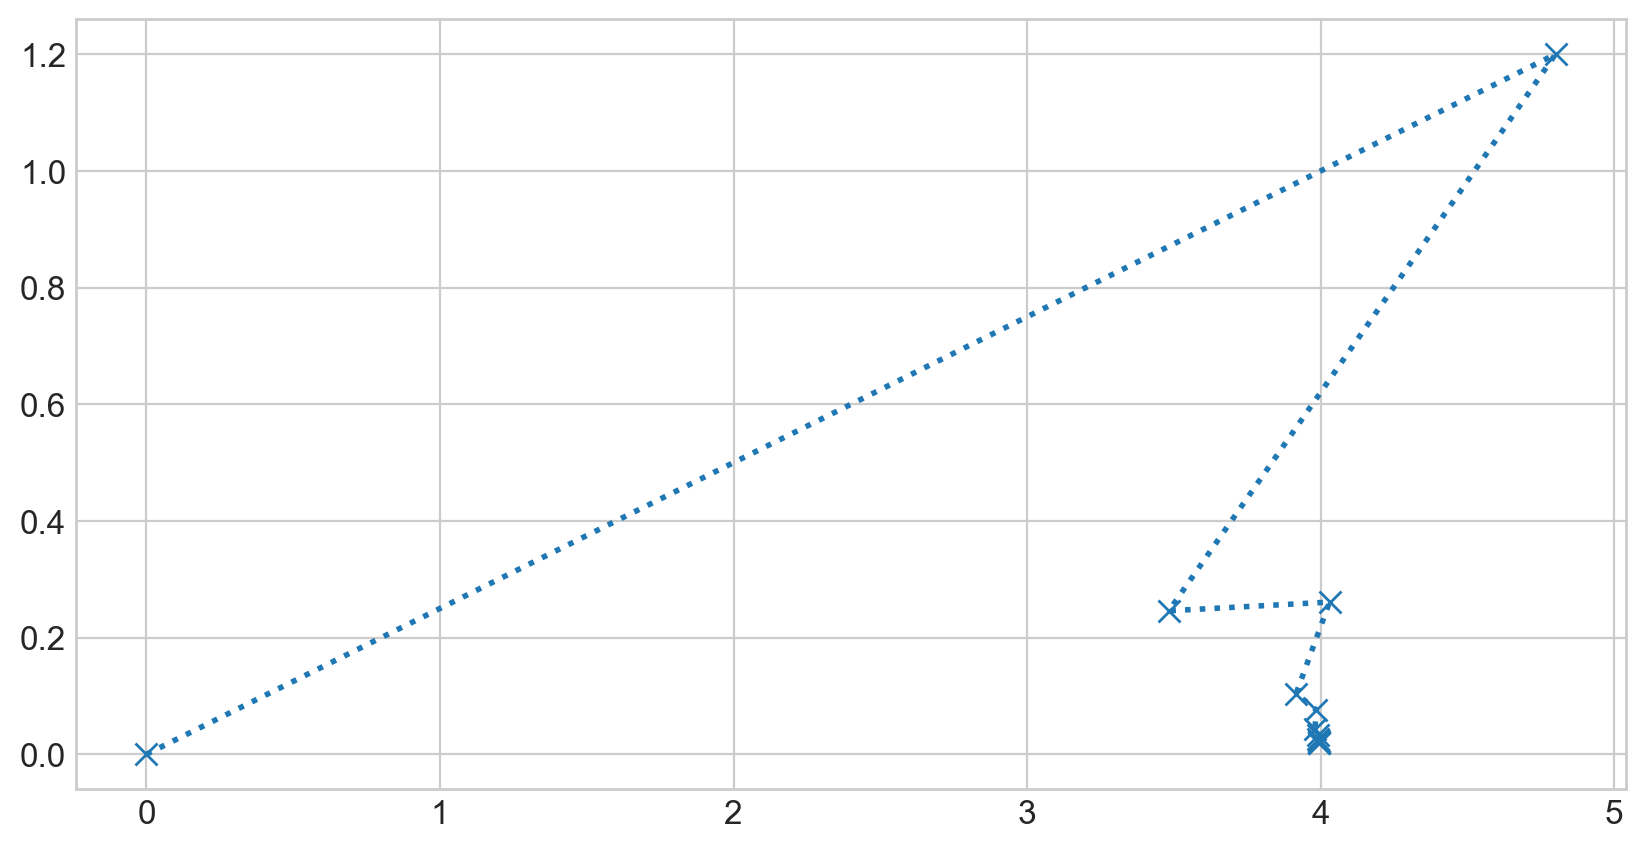

In [13]:
plt.plot(x[:,0], x[:,1], 'x:')   # regarder la convergence

### nxn

Passons à 9x9

In [14]:
N = 9

A = np.random.randint(-10, 10, size=(N,N))
A = A * 1.0                                            # pour passer en reels
A[np.diag_indices(N)] = 0.1 + np.abs(A).sum(axis=0)    # diag dominante
A = A + A.T                                            # symétriser
A = A / np.abs(A).sum(axis=0).mean()                   # normaliser
b = np.random.randint(-10,10,size=(N))

In [15]:
x = minimum_J(np.zeros(N))

In [16]:
A @ x[-1] - b

array([ 0.,  0.,  0., -0.,  0.,  0.,  0., -0., -0.])

In [17]:
print("Converge en %d itérations" % len(x))
x

Converge en 21 itérations


array([[  0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ],
       [ -9.6  , -12.   ,  -7.2  ,  -4.8  ,   8.4  , -10.8  ,   1.2  ,   3.6  ,  -3.6  ],
       [ -7.568, -16.711,  -9.233,  -5.285,   7.174, -15.44 ,   1.092,   6.785,  -1.212],
       [ -8.441, -19.214, -10.675,  -5.756,   6.54 , -17.933,   0.318,   7.387,  -0.017],
       [ -8.489, -20.496, -11.529,  -5.795,   5.85 , -19.398,  -0.235,   7.774,   0.695],
       [ -8.64 , -21.218, -12.052,  -5.759,   5.455, -20.263,  -0.638,   7.92 ,   1.094],
       [ -8.703, -21.627, -12.368,  -5.692,   5.202, -20.783,  -0.89 ,   7.997,   1.326],
       [ -8.749, -21.865, -12.56 ,  -5.635,   5.051, -21.096,  -1.048,   8.031,   1.462],
       [ -8.775, -22.005, -12.675,  -5.59 ,   4.96 , -21.285,  -1.144,   8.048,   1.543],
       [ -8.791, -22.088, -12.745,  -5.559,   4.906, -21.4  ,  -1.203,   8.057,   1.591],
       [ -8.8  , -22.137, -12.787,  -5.539,   4.873, -21.469,  -1.238,   8.061,   1.619],
       [ -

## Introduire de l'inertie

Introduire de l'inertie dans la méthode du gradient. Que constate-t-on ?

#### Réponse

Ajouter de l'inertie dans une méthode itérative veut dire qu'on avance moins vite vers le point suivant :
    
```python
x_next = ...
x = w * x_next + (1 - w) * x
```

avec `w` qui représente la force d'avancée (ou l'inverse du poids de l'inertie).

Dans le cas de la méthode du gradient cela donne :
```python
x_next = x - µ grad_J(x)
x = w * x_next + (1 - w) * x
```
ce qui se développe ainsi :

```python
x = w * (x - µ grad_J(x)) + (1 - w) x
```

ou 


```python
x = x - w * µ grad_J(x)
```

On voit donc qu'ajouter de l'inertie ne fait que modifier le paramètre µ qui justement sert à avancer plus
ou moins vite. µ est déjà une sorte d'inertie.

Donc cela ne change pas la méthode et cela n'amméliore pas l'algorithme.

## Valeur optimale de µ

On note que deux directions de pente successives sont orthogonales si le point suivant est le minumum dans
la direction donnée ($\nabla J ({\bf x}^k$)).

$$\nabla J ({\bf x}^{k+1})^T \; \nabla J ({\bf x}^k) = 0$$

#### Démonstration 


<table><tr>
    <td>
On veut régler µ pour arriver au minimum de J lorsqu'on avance dans la direction $- \nabla J({\bf x}^{k})$.
Cela veut dire que la dérivée partielle de $J({\bf x}^{k+1})$ par rapport à µ doit être
égale à 0 ou bien en faisant apparaitre µ dans l'équation :

$$
\frac{\partial J ({\bf x}^k - µ \; \nabla J ({\bf x}^k))}{\partial µ} = 0
$$

En développant on a

$$
\begin{align}
\frac{\partial J ({\bf x}^{k+1})}{\partial {\bf x}^{k+1}} \; 
\frac{\partial {\bf x}^{k+1}}{\partial µ} & = 0   \\
J'({\bf x}^{k+1}) \, . \, (- \nabla J ({\bf x}^k)) & = 0 \\
(A\, {\bf x}^{k+1}  - b) \, . \, \nabla J ({\bf x}^k) & = 0 \quad \textrm{puisque $A$ est symétrique}\\
\nabla J ({\bf x}^{k+1})  \, . \, \nabla J ({\bf x}^k) & = 0 \quad \textrm{CQFD}
\end{align}
$$


</td><td>
<img src="images/gradient.png" width = "600px"/>
</td></tr></table>


En utilisant cette propriété, évaluer la valeur optimale de µ pour atteindre le minimum dans la direction de
$\nabla J ({\bf x}^k)$.

#### Réponse

On reprend l'avant-dernière ligne de la démonstration et on remplace ${\bf x}^{k+1}$ par
${\bf x}^k - µ \, \nabla J({\bf x}^k)$ :

$$
\begin{align}
( A ({\bf x}^k - µ \, \nabla J({\bf x}^k)) - b ) \, . \, \nabla J ({\bf x}^k)  & = 0 \\
( A {\bf x}^k - b - µ \, A \, \nabla J({\bf x}^k) ) \, . \, \nabla J ({\bf x}^k)  & = 0 \\
( A {\bf x}^k - b ) \, . \, \nabla J ({\bf x}^k) - µ \, A \, \nabla J({\bf x}^k) \, . \, \nabla J ({\bf x}^k)  & = 0 \\
µ & = \frac{\nabla J ({\bf x}^k) \, . \, \nabla J ({\bf x}^k)}{A \, \nabla J({\bf x}^k) \, . \, \nabla J ({\bf x}^k) }
\end{align}
$$

Écrire la méthode du gradient avec le calcul du µ optimal à chaque itération pour résoudre $A {\bf x} = {\bf b}$.

In [18]:
def minimum_J_opt(start_value, e = 0.001):
    x = [np.array(start_value)]
    while True:
        gradJ = grad_J(x[-1])
        µ = np.dot(gradJ, gradJ) / np.dot(A @ gradJ, gradJ)
        x.append(x[-1] - µ * gradJ)
        if np.sum(np.square(x[-1] - x[-2])) < e**2:
            break
        # la suite n'est que des tests pour se protéger
        if np.square(x[-1] - x[-2]).sum() > 1E9:  # au cas où on diverge
            print("DIVERGE")
            break
        if len(x) > 1000:  # c'est trop long, je crains la boucle infinie
            print('Trop long, boucle infinie ?')
            break
    return np.array(x)

In [19]:
print(A)
x = minimum_J_opt(np.zeros(N))
A @ x[-1] - b

[[ 0.929  0.042  0.     0.048 -0.125 -0.055  0.048  0.104  0.007]
 [ 0.042  0.514 -0.083  0.    -0.028 -0.028 -0.042  0.014  0.048]
 [ 0.    -0.083  0.625  0.062 -0.021  0.    -0.09   0.042  0.104]
 [ 0.048  0.     0.062  0.5   -0.014  0.042  0.007  0.111  0.035]
 [-0.125 -0.028 -0.021 -0.014  0.68  -0.062 -0.09   0.021  0.021]
 [-0.055 -0.028  0.     0.042 -0.062  0.458 -0.042  0.014  0.09 ]
 [ 0.048 -0.042 -0.09   0.007 -0.09  -0.042  0.625 -0.028 -0.028]
 [ 0.104  0.014  0.042  0.111  0.021  0.014 -0.028  0.68   0.028]
 [ 0.007  0.048  0.104  0.035  0.021  0.09  -0.028  0.028  0.749]]


array([ 0.,  0.,  0., -0., -0.,  0.,  0.,  0., -0.])

In [19]:
print("Converge en %d itérations" % len(x))
x

Converge en 14 itérations


array([[  0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ],
       [ -6.572,   0.   ,  -8.215,  -3.286,  13.145, -14.788,  -4.929,   0.   ,  -9.858],
       [ -8.177,  -1.657, -10.747,  -1.566,  10.713, -13.488,  -5.569,  -1.62 , -12.125],
       [ -7.807,  -1.108, -11.181,  -2.418,  11.378, -14.229,  -5.094,  -2.731, -13.429],
       [ -8.142,  -1.536, -11.557,  -2.121,  10.966, -14.196,  -5.064,  -3.057, -13.713],
       [ -8.067,  -1.419, -11.604,  -2.239,  11.087, -14.326,  -4.989,  -3.301, -13.94 ],
       [ -8.135,  -1.505, -11.672,  -2.186,  11.019, -14.319,  -4.975,  -3.37 , -13.982],
       [ -8.122,  -1.482, -11.68 ,  -2.204,  11.045, -14.342,  -4.962,  -3.422, -14.02 ],
       [ -8.136,  -1.499, -11.693,  -2.193,  11.033, -14.34 ,  -4.958,  -3.436, -14.026],
       [ -8.133,  -1.494, -11.694,  -2.196,  11.039, -14.344,  -4.956,  -3.447, -14.033],
       [ -8.136,  -1.497, -11.696,  -2.193,  11.037, -14.343,  -4.955,  -3.45 , -14.033],
       [ -